# 35 — Calculate nested liquidity-horizon Expected Shortfall

Measure the average loss beyond the 97.5% loss threshold and apply the five nested liquidity horizons.

ES means Expected Shortfall. The calculation first forms joint 10-day portfolio outcomes. Longer-horizon factors enter nested subsets; standalone factor ES values are not simply added.

This step uses: Modellable factor P&L, factor liquidity horizons and the selected historical period.

It produces: 10-day ES, every nested component and liquidity-horizon-adjusted ES.

> Basel norm applied: MAR33.3–MAR33.4 use a one-tailed 97.5% ES and 10/20/40/60/120-day nested horizons.

$$ES^{LH}=\sqrt{ES_{10}^2+\sum_{j=2}^{5}ES_j^2\frac{LH_j-LH_{j-1}}{10}}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260901T122303Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
components=stage('10_liquidity_horizon_es_components'); rowset=components[(components.scope=='ALL')&(components.period=='CURRENT')&(components.factor_set=='FULL')].copy()
shown=rowset.copy(); shown['subset_es_inr_crore']=shown.subset_es_inr/INR_CRORE; shown['squared_contribution_inr_crore_squared']=shown.squared_contribution/(INR_CRORE**2)
display(shown[['liquidity_horizon_days','subset_es_inr_crore','scaling_increment','squared_contribution_inr_crore_squared']])
base=rowset.iloc[0]; print(f"10-day portfolio ES = {money(base.subset_es_inr)}. Longer-horizon squared contributions are then added before taking the square root.")

,liquidity_horizon_days,subset_es_inr_crore,scaling_increment,squared_contribution_inr_crore_squared
0,10,6.2486,1.0000,39.0453
1,20,4.8928,1.0000,23.9391
2,40,0.3047,2.0000,0.1857
3,60,0.2369,2.0000,0.1122
4,120,0.0834,6.0000,0.0417


10-day portfolio ES = INR 6.25 crore. Longer-horizon squared contributions are then added before taking the square root.


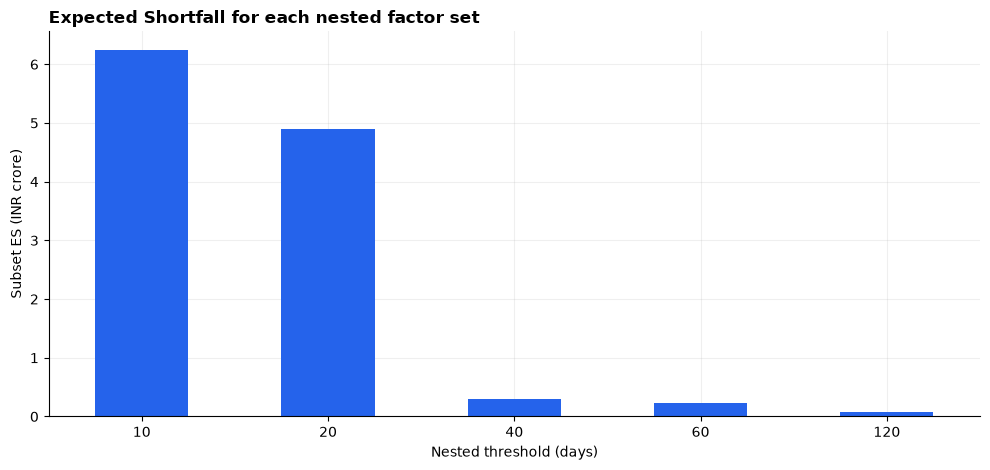

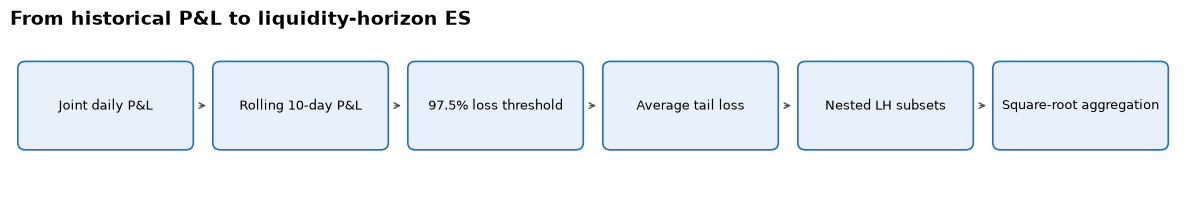

In [3]:
ax=(rowset.set_index('liquidity_horizon_days').subset_es_inr/INR_CRORE).plot(kind='bar',color='#2563EB'); ax.set_xlabel('Nested threshold (days)'); ax.set_ylabel('Subset ES (INR crore)'); ax.set_title('Expected Shortfall for each nested factor set',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()
draw_flow(['Joint daily P&L','Rolling 10-day P&L','97.5% loss threshold','Average tail loss','Nested LH subsets','Square-root aggregation'],'From historical P&L to liquidity-horizon ES',wrap_after=6)

The bars show Expected Shortfall calculated from nested factor subsets. The 10-day bar contains all modellable factors; each longer threshold retains only factors whose assigned horizon is at least that threshold. These bars are intermediate subset ES values, not separate capital charges to be added directly. The flow diagram shows how rolling losses, tail averaging and square-root liquidity-horizon aggregation convert historical P&L into the final adjusted ES.